# Experiment A-05 - NN Architecture Dependence  (more complex architecture)

## **🔴 Context**

- Until now, for the neural network only 2 hidden layers, a width of 32 and activation function tanh was used.
- More complex architectures could improve performance, but are computationally more expensive.

---

## **🟡 Experiment Questions**

#### **Q1 - Does more complex MLP architectures perform better?**

No, there is no significant differences in the performance of the different schemes.

#### **Q2 - How computationally expensive are more complex architectures?**

| H_ W__ | rel. H2 W32 (default) |
|------|---|
| H2 W64   | 2.3 x |
| H3 W64   | 3.4 x |
| H3 W128  | 12.1 x |

#### **Q3 - Does a different activation function yield better results?**

GELU achieves in total slightly better results than tanh.


---


## **🟢 Short Result**
#### No significant improvents through more complex architectures despite higher computational cost. gelu achieves slightly better results than tanh.


---

## **0. Setup**

In [1]:
# Loading packages
using Revise
using NeuralParam
using CairoMakie
using Statistics

In [2]:
# Define experiment
EXP = "exp_A_05_arch";

"exp_A_05_arch"

## **1. Training**

In [3]:
# Define notebook picture scaling
NB_TRAIN = (; size = (900, 600));

In [4]:
# Define experiment and schemes
SCHEMES = ["NLW_H2_W64", "NLW_H3_W64", "NLW_H3_W128", "NLW_gelu"]
LABELS = ["H2 W64", "H3 W64", "H3 W128", "GELU"]
COLORS = [JL_RED, JL_BLUE, JL_GREEN, JL_PURPLE]
STEPS = 100:500;;

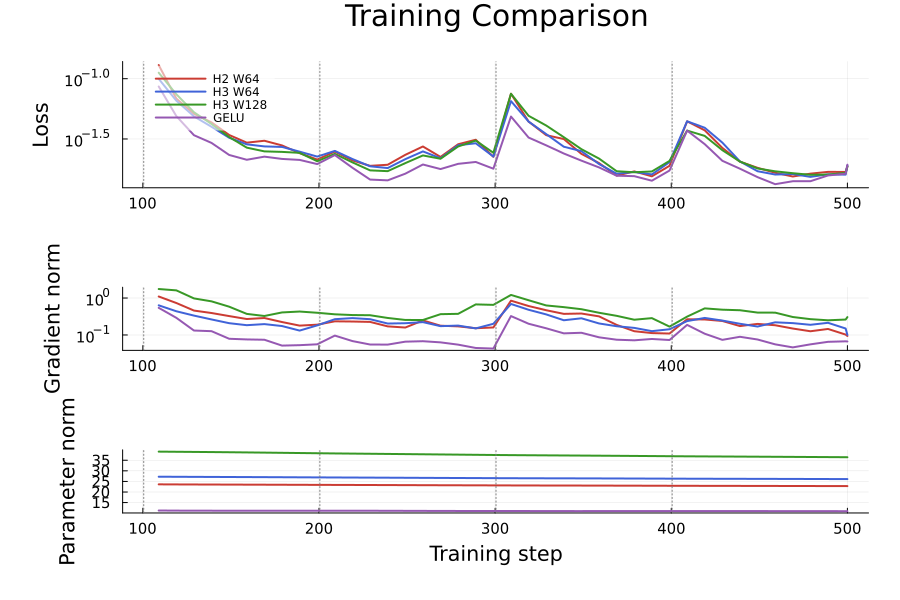

In [5]:
# Plot training comparison
plot_training_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

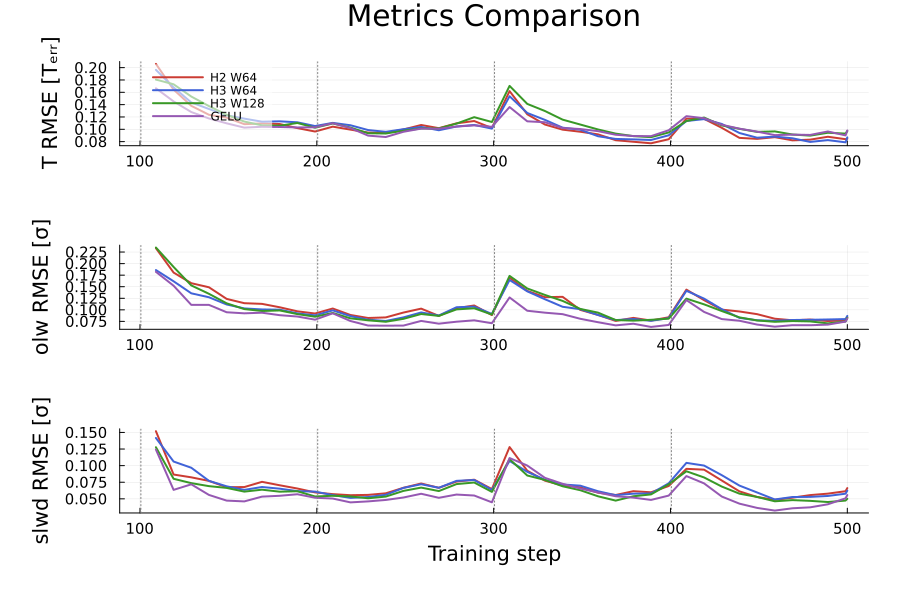

In [6]:
# Training metrics comparison
plot_metrics_comp(; exp = EXP, names = SCHEMES, labels = LABELS, colors = COLORS, steps = STEPS, plot_kwargs = NB_TRAIN)

## **2. Rollouts**

In [8]:
# Define notebook picture scaling
NB_ROLLOUT = (; size = (1200, 400));

In [ ]:
# Load NeuralLW with default arch (H2 W32) rollouts
EXP_H2W32 = "exp_A_04_seeding_spinup";
skill_H2W32 = collect_rollouts(EXP_H2W32, ["NLW_seed1_skill", "NLW_seed2_skill", "NLW_seed3_skill"]);
stab_H2W32 = collect_rollouts(EXP_H2W32, ["NLW_seed1_stab", "NLW_seed2_stab", "NLW_seed3_stab"]);

In [ ]:
# Load different architectures scheme rollouts
SKILL_NAMES = [
    "OBLW_skill",
    "NLW_H2_W64_skill",
    "NLW_H3_W64_skill",
    "NLW_H3_W128_skill", 
    "NLW_gelu_skill", 
]
STAB_NAMES = replace.(SKILL_NAMES, "skill" => "stab")

skill_arch = collect_rollouts(EXP, SKILL_NAMES);
stab_arch = collect_rollouts(EXP, STAB_NAMES);

In [15]:
# Merge rollouts and define labels and colors
skill = merge(skill_H2W32, skill_arch);
stab = merge(stab_H2W32, stab_arch);

LABELS = ["H2 W64 Seed 1", "H2 W64 Seed 2", "H2 W64 Seed 3", "OBLW", "H2 W64", "H3 W64", "H3 W128", "GELU"]
COLORS = [:black, :black, :black, :grey, JL_BLUE, JL_GREEN, JL_RED, JL_PURPLE];

### 2.1. Skill (31 days)

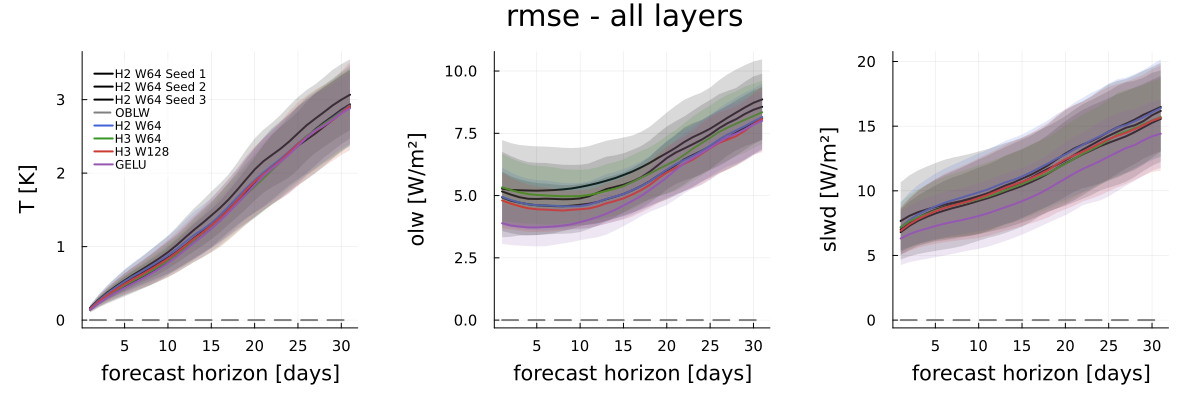

In [16]:
# Plot rmse comparison
plot_rollout(rollouts = skill, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

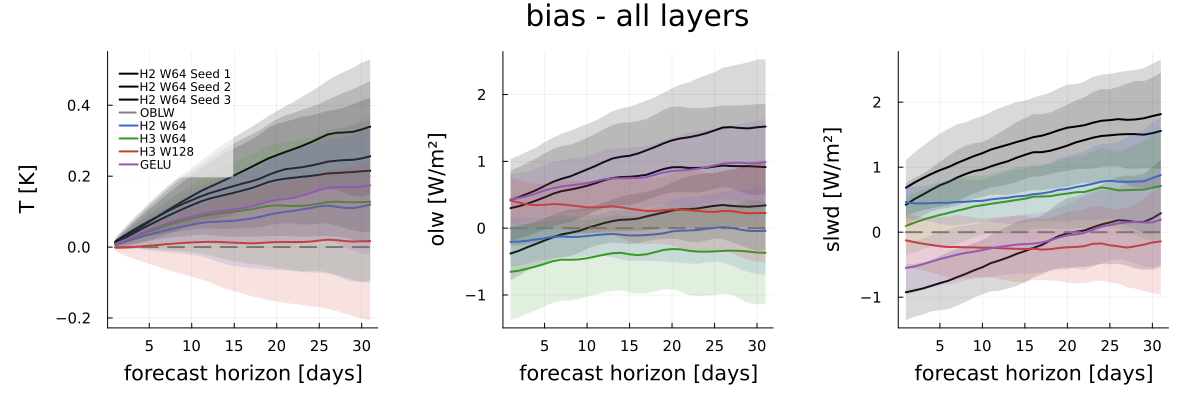

In [17]:
# Plot bias comparison
plot_rollout(rollouts = skill, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

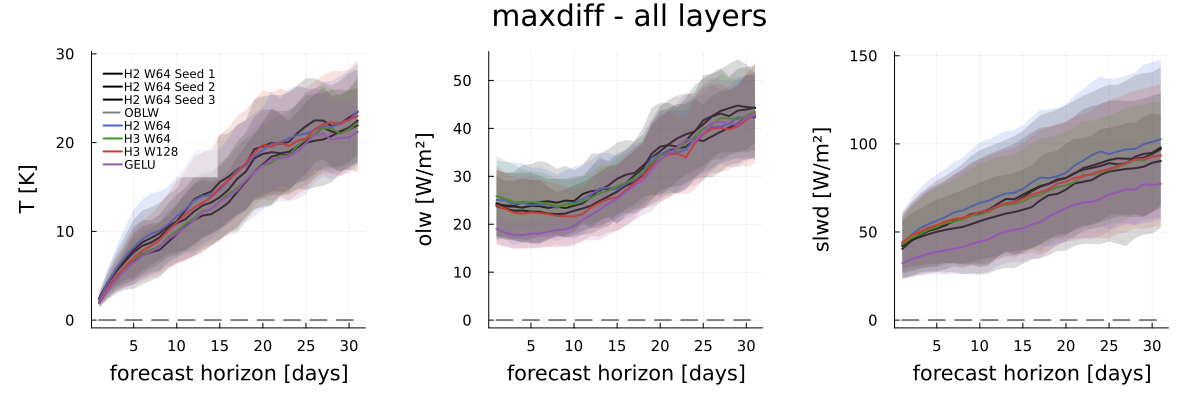

In [18]:
# Plot maxdiff comparison
plot_rollout(rollouts = skill, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

### 2.2. Stability (365 days)

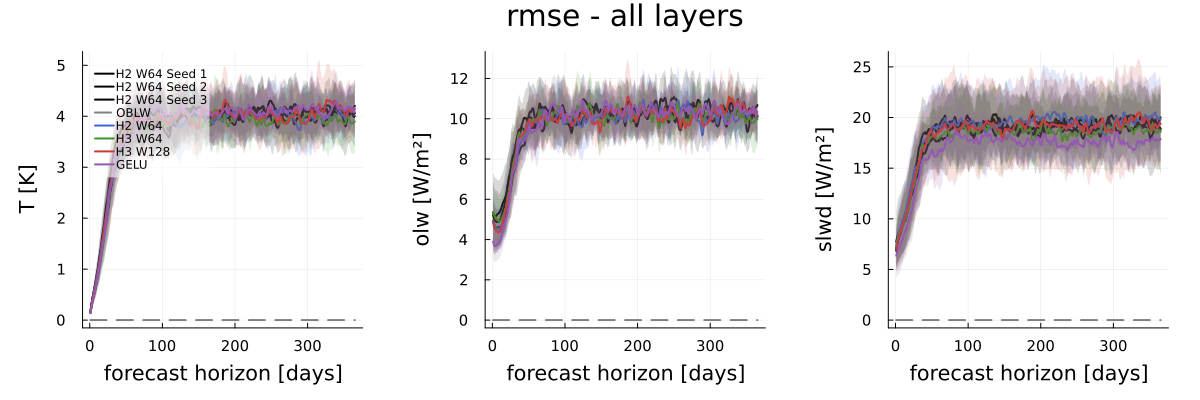

In [19]:
# Plot rmse comparison
plot_rollout(rollouts = stab, metric = :rmse, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

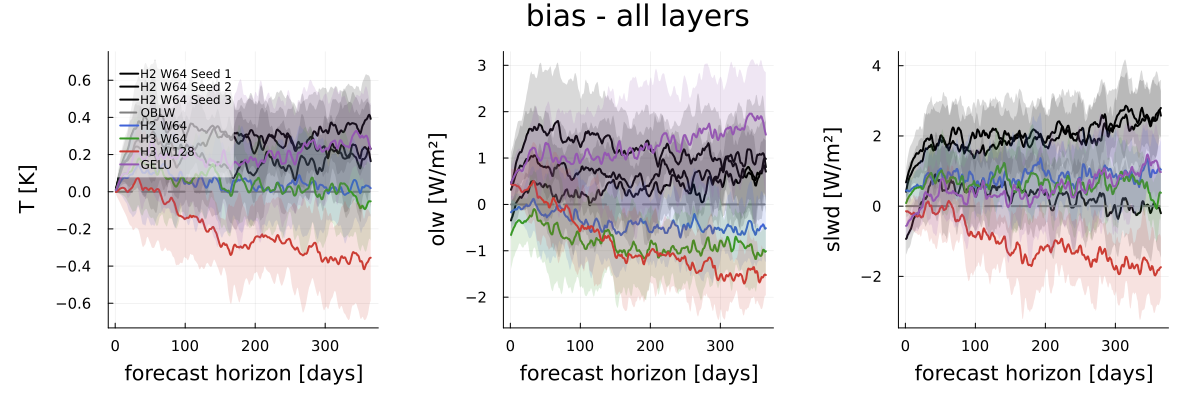

In [20]:
# Plot bias comparison
plot_rollout(rollouts = stab, metric = :bias, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

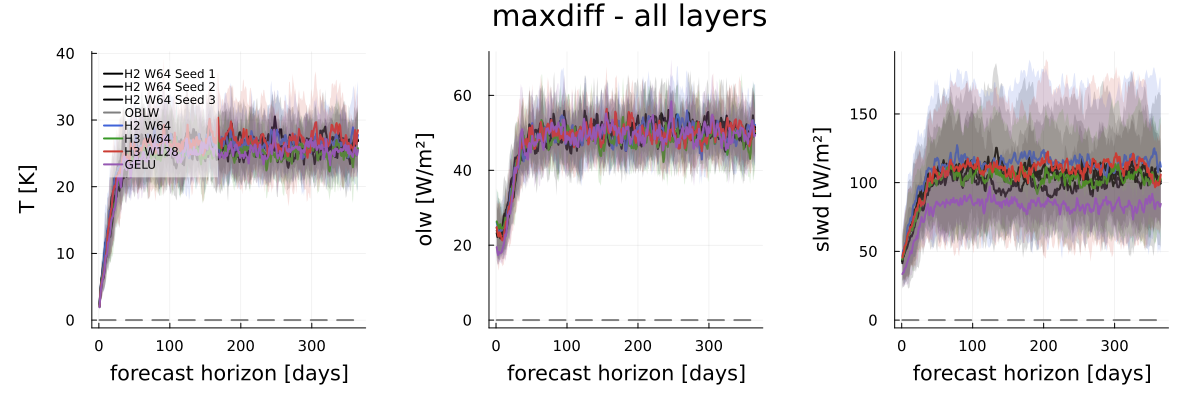

In [21]:
# Plot maxdiff comparison
plot_rollout(rollouts = stab, metric = :maxdiff, labels = LABELS, colors = COLORS, plot_kwargs = NB_ROLLOUT)

## **3. Benchmark**

In [33]:
# Define spectral grid for benchmark evaluation
using SpeedyWeather
SG = SpectralGrid(trunc = 31, nlayers = 8);

In [34]:
# Load schemes
schemes = merge(
    (; OBLW = build_scheme(:OBLW, SG)),
    collect_schemes("exp_A_02_NLW_outputForms", ["NLW_planck"]),
    collect_schemes(EXP, ["NLW_H2_W64", "NLW_H3_W64", "NLW_H3_W128", "NLW_gelu"]),
);

In [35]:
# Evaluate and print bencnhmark results
res = benchmark_scheme(schemes; spectral_grid = SG)
print_benchmark(res; baseline = :OBLW);


scheme                    ms/step   med/min     KB/step      allocs    rel.
---------------------------------------------------------------------------
OBLW                       0.9063      1.18         0.0           0    1.0×
NLW_planck                 9.5496      1.43      6187.5      101376  10.54×
NLW_H2_W64                22.1126      1.22      7524.0      101376   24.4×
NLW_H3_W64                32.0767      1.25      9702.0      129888  35.39×
NLW_H3_W128              115.3191      1.21     12672.0      129888 127.24×
NLW_gelu                  11.1621      1.19      6187.5      101376  12.32×
